In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from models import AE, CNN_AE_fmnist, Autoencoder_linear_contra_fmnist, MLP_VAE_fmnist, CNN_VAE_fmnist, CNN_AE_fmnist_noiser, CNN_AE_fmnist_noiser_sig, CNN_AE_fmnist_noiser_2sig, CNN_AE_fmnist_noiser_2sig_big

from torchvision import datasets, transforms

import zipfile
import ot

import shutil
import os
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big, VAE_big_consti

device = ("cuda" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training

2024-01-21 13:03:41.539300: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-01-21 13:03:43.417034: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-01-21 13:03:43.417158: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-01-21 13:03:43.417278: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-01-21 13:03:43.418901: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:13:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.15GiB deviceMemoryBandwidth: 1.76TiB/s
2024-01-21 13:03:43.418957: I tensorflow/stream_executor/cuda/cuda_gpu_

In [2]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

def get_kl_divergences(mu_so, std_so, mu_po, std_po):
    dists = torch.tensor([]).to(device)
    for i in range(64):
        mu_po_n = mu_po[i]
        std_po_n = std_po[i]
        distances = 0.5 * torch.sum (((mu_so - mu_po_n)**2 / std_po_n**2) + (std_so**2 / std_po_n**2) - 1 - torch.log(std_so) + torch.log(std_po_n))
        #print(distances.item())
        dists = torch.cat([dists, distances.unsqueeze(0)])
    return dists

def give_mean_sliced_wass_dist(allChImage1, allChImage2):
    mean_wass = 0
    for i in range(3):
        wassDistance = ot.sliced_wasserstein_distance(allChImage1[i], allChImage2[i], seed=0)  
        mean_wass = mean_wass + wassDistance
    return mean_wass/3

In [3]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [4]:
'''
root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     '''

"\nroot = 'data_faces/img_align_celeba'\nimg_list = os.listdir(root)\nprint(len(img_list))\n     "

In [5]:
'''
df = pd.read_csv("list_attr_celeba.csv")
df = df[['image_id', 'Smiling']]'''

'\ndf = pd.read_csv("list_attr_celeba.csv")\ndf = df[[\'image_id\', \'Smiling\']]'

In [6]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [7]:
'''
s0 = 0
s1 = 0

num = 200000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 200000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [8]:
'''
img_list = os.listdir('data_cel/smile/')
img_list.extend(os.listdir('data_cel/no_smile/'))'''

"\nimg_list = os.listdir('data_cel/smile/')\nimg_list.extend(os.listdir('data_cel/no_smile/'))"

In [9]:
'''print("Images: ", len(img_list))
'''

'print("Images: ", len(img_list))\n'

In [10]:
'''transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel', transform=transform)'''

"transform = transforms.Compose([\n          transforms.Resize((64, 64)),\n          transforms.ToTensor()\n          ])\n\nbatch_size = 64\nceleba_data = datasets.ImageFolder('data_cel', transform=transform)"

In [11]:
'''print(celeba_data.classes)
print(len(celeba_data))'''

'print(celeba_data.classes)\nprint(len(celeba_data))'

In [12]:
'''
train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])
train_data_size = len(train_set)
test_data_size = len(test_set)'''

'\ntrain_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])\ntrain_data_size = len(train_set)\ntest_data_size = len(test_set)'

In [13]:
'''trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)
'''

'trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)\ntestLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)\n'

In [14]:
'''

print(train_data_size)
print(test_data_size)'''

'\n\nprint(train_data_size)\nprint(test_data_size)'

In [43]:
image_channels = 3
train_data_size = 105000
epochs = 200

#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

#model = VAE(image_channels=image_channels).to(device)
#model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_simple_CNN_VAE_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

#model = VAE_big(image_channels=image_channels).to(device)
#model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

with torch.no_grad():

    model = VAE_big_consti(image_channels=image_channels).to(device)
    model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_ConstistentDimRedu_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

    # Set the model to evaluation mode (if needed)
    model.eval()

###### How to calculate KL divergence when you have a multivariate Gaussian

KL_cur = 0.5 * torch.sum (((mu_so - mu_po)**2 / std_po**2) + (std_so**2 / std_po**2) - 1 - torch.log(std_so) + torch.log(std_po))


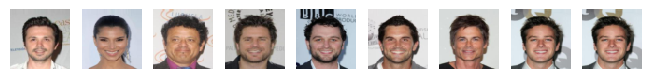

In [44]:
test_ne = torch.load("/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/neighbours13.pt")

with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(1, 11,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(test_ne[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [45]:
source_im = test_ne[-1].unsqueeze(0)
target_im = test_ne[-3].unsqueeze(0)
source_im.shape, target_im.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [54]:
# Load the autonoiser

from models import AE, CNN_AE_fmnist, Autoencoder_linear_contra_fmnist, MLP_VAE_fmnist, CNN_VAE_fmnist, CNN_AE_fmnist_noiser, CNN_AE_fmnist_noiser_sig, CNN_AE_fmnist_noiser_2sig, CNN_AE_fmnist_noiser_2sig_big
latent_dim = 4
no_channels = 3
activation_cnn_noiser = activation_cnn_noiser = nn.ReLU()

autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig_big(latent_dim, no_channels, activation_cnn_noiser).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoenoiser_cnn.parameters(), lr=0.0001)

adv_alpha = 0.85
noiser_epochs = 100000

In [55]:

noise_outputs = autoenoiser_cnn(source_im)
noise_outputs

tensor([[[[-0.3977,  0.1674, -0.3992,  ...,  0.1689, -0.3989,  0.3107],
          [-0.1255, -0.3315, -0.1369,  ..., -0.3302, -0.1353, -0.0986],
          [-0.3944,  0.1592, -0.3969,  ...,  0.1637, -0.3987,  0.3096],
          ...,
          [-0.1280, -0.3306, -0.1390,  ..., -0.3280, -0.1379, -0.0991],
          [-0.3938,  0.1638, -0.3998,  ...,  0.1675, -0.3980,  0.3092],
          [-0.0942,  0.0740, -0.0951,  ...,  0.0763, -0.0936,  0.0541]],

         [[ 0.3157, -0.2198,  0.3194,  ..., -0.2194,  0.3193,  0.2214],
          [ 0.0690,  0.6017,  0.0610,  ...,  0.6004,  0.0603,  0.1152],
          [ 0.3159, -0.2089,  0.3132,  ..., -0.2145,  0.3171,  0.2173],
          ...,
          [ 0.0686,  0.5976,  0.0584,  ...,  0.5947,  0.0598,  0.1113],
          [ 0.3153, -0.2159,  0.3174,  ..., -0.2153,  0.3176,  0.2193],
          [ 0.2277,  0.1089,  0.2303,  ...,  0.1114,  0.2301, -0.0889]],

         [[ 0.1564,  0.2174,  0.1478,  ...,  0.2190,  0.1493,  0.2786],
          [ 0.3524, -0.0802,  

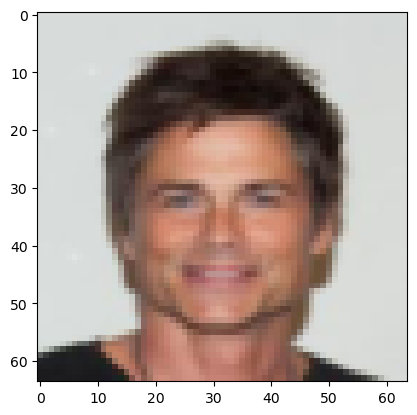

In [48]:
plt.imshow(target_im[0].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [61]:
train_loss = []

for epoch in range(noiser_epochs):
    #t_i = 0
    # training our model
    #for idx, (image, label) in enumerate(trainLoader):
    #images, label = image.to(device), label.to(device)
    #print("images.shape", images.shape)
    images = source_im
    optimizer.zero_grad()
    data = images.to(device)
    noise_outputs = autoenoiser_cnn(data)

    if(epoch==2):
        break
    noise_outputs = (noise_outputs - 1.0)*2.0
    with torch.no_grad():
        adv_gen,_,_ = model(data + noise_outputs)
    
    #adv_gen,_,_ = model(data)

    with torch.no_grad():

        #ae_perturbed_embeds = model_cnnvae_.encoder(adv_gen) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
        ae_perturbed_embeds = model.encoder(data + noise_outputs) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
        mu1, logvar1 = model.fc1(ae_perturbed_embeds), model.fc2(ae_perturbed_embeds)
        std1 = logvar1.mul(0.5).exp_()
        esp1 = torch.randn(*mu1.size()).to(device)
        z1 = mu1 + std1 * esp1

        #train_embeds = model_cnnvae_.encoder(adv_batches[t_i].to(device))
        train_embeds = model.encoder(data.to(device))
        mu2, logvar2 = model.fc1(train_embeds), model.fc2(train_embeds)
        std2 = logvar2.mul(0.5).exp_()
        esp2 = torch.randn(*mu2.size()).to(device)
        z2 = mu2 + std2 * esp2

        #print("adv_gen.shape", adv_gen.shape)
        #print("data.shape", data.shape)
        
        fooled_out= model(adv_gen)
        adv_embeds = model.encoder(adv_gen.to(device))
        mu3, logvar3 = model.fc1(adv_embeds), model.fc2(adv_embeds)
        std3 = logvar3.mul(0.5).exp_()
        esp3 = torch.randn(*mu3.size()).to(device)
        z3 = mu3 + std3 * esp3


        target_embeds = model.encoder(target_im.to(device))
        mu4, logvar4 = model.fc1(target_embeds), model.fc2(target_embeds)
        std4 = logvar4.mul(0.5).exp_()
        esp4 = torch.randn(*mu4.size()).to(device)
        z4 = mu4 + std4 * esp4


    print("criterion(mu1, mu2)", criterion(mu1, mu2))
    print("std1, std2", std1, std2)
    print("criterion(std1, std2)", criterion(std1, std2))
    
    adv_gen_loss = criterion(mu1, mu2) + criterion(std1, std2)

    #loss = criterion(adv_embeds, target_embeds)
    loss = ( criterion(mu3, mu4) + criterion(std3, std4) )

    print("adv_gen_loss", adv_gen_loss)
    print("loss", loss)

    #total_loss = loss * (1.0-adv_alpha)  + adv_gen_loss * adv_alpha
    
    total_loss = ( adv_gen_loss * (1.0-adv_alpha) ) + (loss * adv_alpha)
    total_loss = total_loss.requires_grad_()
    total_loss.backward()
    optimizer.step()
    
    #t_i +=1

    print(f'Epoch [{epoch+1}/{noiser_epochs}], Loss: {total_loss.item():.4f}')
# save the model
#torch.save(autoenoiser_cnn.state_dict(), '/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'')

torch.save(autoenoiser_cnn.state_dict(), '/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/targetNoiser_vae_consti_red_celebA_advAlpha'+str(adv_alpha)+'_')

criterion(mu1, mu2) tensor(33651.2891, device='cuda:0')
std1, std2 tensor([[       inf, 8.5104e+05, 7.9923e+05, 5.3018e-24, 2.6134e+16, 5.7366e-27,
                inf,        inf, 1.4761e+25, 2.5816e-12, 9.2703e-18, 2.2211e-36,
         7.3200e-41, 5.1295e+30, 1.5408e-17, 1.3826e-04, 1.2655e+32, 0.0000e+00,
         3.0202e+05, 2.6083e-10, 1.5267e+31, 5.8827e+27, 7.1602e+15, 3.6764e+01,
         1.9035e+14, 4.9937e-23, 1.0005e-41,        inf, 2.5838e-18, 0.0000e+00,
         3.5466e-06, 6.1634e-28, 5.1219e-05, 1.0089e-43, 1.6426e-24,        inf,
         2.0406e+37, 2.1327e+23, 1.0628e+19, 2.7953e+35, 1.9669e+23, 1.5835e-43,
         9.8944e-26, 3.2467e-22, 3.3041e+11, 7.2242e+02, 4.9655e+06, 3.2619e+22,
                inf, 3.9391e+03, 2.2163e+29, 9.3994e+01, 0.0000e+00, 3.9225e+00,
         2.8825e-37, 0.0000e+00, 3.8470e-18, 1.2150e-38, 1.0539e-01, 8.6479e-01,
                inf,        inf,        inf, 1.6978e+26, 4.0631e-23, 1.0301e+16,
         7.3869e-20,        inf,        in

In [ ]:
# load the autonoiser

autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/targetNoiser_vae_celebA_advAlpha'+str(adv_alpha)+'_'))

# Set the model to evaluation mode (if needed)
autoenoiser_cnn.eval()

In [ ]:

viz_train = images.reshape(-1, 3, 64, 64).to(device)
#viz_adv = images.reshape(-1, 1, 64, 64).to(device)

In [ ]:
viz_train.shape

In [ ]:
num_steps = 200
path = torch.linspace(0.0, 3.0, num_steps).to(device)

nth_image_ind = 0


#for nth_image_ind in range(viz_train.shape[0]):

n_th_image = viz_train[nth_image_ind].unsqueeze(0)
#n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)

print(n_th_image.shape)
noise_outputs = autoenoiser_cnn(n_th_image)
noise_outputs = (noise_outputs - 1.0)*2.0

so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

scaled_noises = noise_outputs * scales

scale_noised_images = n_th_image + scaled_noises

adv_gen,_,_ = model(scale_noised_images)
#print("adv_gen.shape", adv_gen.shape)
#print("n_th_image.shape", n_th_image.shape)

#diff = torch.sqrt((adv_gen - n_th_image)**2)
each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
#print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
fooled_out, _, _= model(adv_gen)

each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

'''bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)

    if(True in bool_mix):
        print("bool_mix ", bool_mix )
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'''

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(adv_gen[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(fooled_out[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [ ]:
num_steps = 200
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0

critical_inds_list = []

all_selected_adv_gens = torch.tensor([]).to(device)
all_selected_scale_noised_images = torch.tensor([]).to(device)
all_selected_n_th_image = torch.tensor([]).to(device)

for nth_image_ind in range(viz_train.shape[0]):

    n_th_image = viz_train[nth_image_ind].unsqueeze(0)
    #n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


    noise_outputs = autoenoiser_cnn(n_th_image)
    noise_outputs = (noise_outputs - 1.0)*2.0

    so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
    scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

    scaled_noises = noise_outputs * scales

    scale_noised_images = n_th_image + scaled_noises
    n_th_image_trick = n_th_image + scaled_noises*0.0
    adv_gen,_,_ = model(scale_noised_images)

    
    #diff = torch.sqrt((adv_gen - n_th_image)**2)
    each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_adv_gen_mse = torch.sqrt((adv_gen - adv_gen[0].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
    fooled_out, _, _= model(adv_gen)

    #each_fooled_out_mse = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(2, 3), keepdim=True).squeeze()
    each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_fooled_out_mse = torch.sqrt((fooled_out - fooled_out[-1].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_fooled_out_mse.max(), each_fooled_out_mse.min()", each_fooled_out_mse.max(), each_fooled_out_mse.min())
    #print("each_adv_gen_mse.max(), each_adv_gen_mse.max()", each_adv_gen_mse.max(), each_adv_gen_mse.min())
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.021)

    only_fooled_out_loss = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()

    bool_mix = (only_fooled_out_loss > 0.02) * (each_adv_gen_mse < 0.15)

    #bool_mix = (each_adv_gen_mse < 0.16) * (each_fooled_out_mse > 0.25)

    #bool_mix = (each_fooled_out_mse > 0.1)
    
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.02)



    if(True in bool_mix):
        #print("bool_mix ", bool_mix )

        selected_adv_gens = adv_gen[bool_mix]
        selected_scale_noised_images = scale_noised_images[bool_mix]
        selected_n_th_image = n_th_image_trick[bool_mix]

        all_selected_adv_gens = torch.cat((all_selected_adv_gens, selected_adv_gens))
        all_selected_scale_noised_images = torch.cat((all_selected_scale_noised_images, selected_scale_noised_images))
        all_selected_n_th_image = torch.cat((all_selected_n_th_image, selected_n_th_image))
        #print("all_selected_adv_gens.shape", all_selected_adv_gens.shape)
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), only_fooled_out_loss.cpu().detach().numpy())
    plt.xlabel("distance of distorted image from the input image")
    plt.ylabel("distance of output image from the target image")

In [ ]:
len(critical_inds_list)

In [ ]:
all_selected_adv_gens.shape

In [ ]:
fooled_out_act, _, _= model(all_selected_adv_gens)


In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_adv_gens[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(fooled_out_act[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_n_th_image[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()